In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import glob

In [12]:
DATA_DIR = Path("data_background_rate_fig_1/06/trial_0")

population_names = [
    "L23E","L23I",
    "L4E","L4I",
    "L5E","L5I",
    "L6E","L6I"
]

BIN_SIZE = 1.0          # ms
WINDOW = 200            # ms
STEP = 20               # ms

T_START = 500
T_STOP = 10500

SAMPLE_SIZE = 300

RNG = np.random.default_rng(42)

In [13]:
def load_population(population):

    files = sorted(DATA_DIR.glob(f"spike_recorder-7717{population}-*.dat"))

    dfs = []

    for file in files:

        df = pd.read_csv(
            file,
            sep=r"\s+",
            comment="#",
            skiprows=2
        )

        df.columns = ["sender","time"]

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [18]:
def build_spike_matrix(df,
                       sample_size=300,
                       bin_size=1):

    # Keep only recording interval
    df = df[(df.time >= T_START) & (df.time < T_STOP)]

    # Unique neurons
    neurons = np.unique(df.sender.values)

    # Randomly sample neurons
    if len(neurons) > sample_size:
        neurons = RNG.choice(
            neurons,
            sample_size,
            replace=False
        )
        df = df[df.sender.isin(neurons)]

    # Relabel neurons to consecutive indices
    neurons, rows = np.unique(df.sender.values,
                              return_inverse=True)

    # Convert spike times to bin indices
    cols = ((df.time.values - T_START) // bin_size).astype(np.int32)

    # Remove possible out-of-range bins
    valid = (cols >= 0) & (cols < int((T_STOP - T_START) / bin_size))
    rows = rows[valid]
    cols = cols[valid]

    # Allocate binary spike matrix
    X = np.zeros(
        (len(neurons), int((T_STOP - T_START) / bin_size)),
        dtype=np.uint8
    )

    # Vectorized assignment
    X[rows, cols] = 1

    # Remove silent neurons
    X = X[X.sum(axis=1) > 0]

    return X

In [19]:
def sliding_synchrony(X,
                      window=200,
                      step=20):

    win_bins = int(window/BIN_SIZE)
    step_bins = int(step/BIN_SIZE)

    synchrony = []
    times = []

    for start in range(
        0,
        X.shape[1]-win_bins+1,
        step_bins
    ):

        Xw = X[:,start:start+win_bins]

        spike_counts = Xw.sum(axis=1)

        active = spike_counts>0

        Xw = Xw[active]
        spike_counts = spike_counts[active]

        if len(spike_counts)<2:

            synchrony.append(np.nan)

            times.append(
                T_START+
                start+
                window/2
            )

            continue

        C = Xw @ Xw.T

        norm = np.sqrt(
            np.outer(
                spike_counts,
                spike_counts
            )
        )

        S = C / norm

        np.fill_diagonal(S, np.nan)

        synchrony.append(
            np.nanmean(S)
        )

        times.append(
            T_START+
            start+
            window/2
        )

    return np.array(times), np.array(synchrony)

In [20]:
results = {}

for pop in range(8):

    print(population_names[pop])

    df = load_population(pop)

    X = build_spike_matrix(df)

    t,s = sliding_synchrony(X)

    results[population_names[pop]] = (t,s)

L23E
L23I
L4E
L4I
L5E
L5I
L6E
L6I


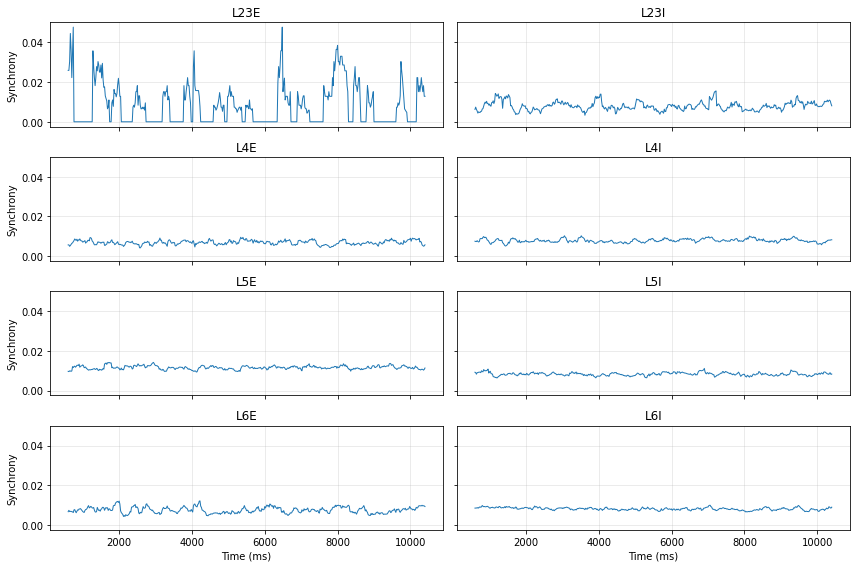

In [21]:
fig,axs = plt.subplots(
    4,
    2,
    figsize=(12,8),
    sharex=True,
    sharey=True
)

axs = axs.ravel()

for ax,name in zip(axs,population_names):

    t,s = results[name]

    ax.plot(t,s,lw=1)

    ax.set_title(name)

    ax.grid(alpha=0.3)

for ax in axs[-2:]:

    ax.set_xlabel("Time (ms)")

for ax in axs[::2]:

    ax.set_ylabel("Synchrony")

plt.tight_layout()

plt.show()